Lets see how two alanine molecules orient themselves using CREST conformer generation.
To do this we will constrain the system in a spherical region using the `SphericalWall` constraint.
We start by setting up a system of two alanine molecules in a relatively small space.

## Initial imports

In [1]:
import sys
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import scm.plams as plams
from scm.conformers import ConformersJob

try:
    from scm.plams import view  # view molecule using AMSview in a Jupyter Notebook in AMS2026+

    _has_view = True
except ImpoGrtError:
    from scm.plams import plot_molecule  # plot molecule in a Jupyter Notebook in AMS2023+

    _has_view = False

    def view(molecule, ax=None, **kwargs):
        plot_molecule(molecule, ax=ax)


# This seed will used in the initial dimer creation and for the starting MD velocities in conformers generation
# Due to numerical aspects it does not guarantee full reproducibility.
seed = random.randint(1, 10000000)
print(f"Seed used for stochastic aspects is {seed}.")

# this line is not required in AMS2025+
plams.init();

Seed used for stochastic aspects is 489563.
PLAMS working folder: /path/plams/examples/ConformersMultipleMolecules/plams_workdir


## Single alanine molecule

[19.03|15:42:16] Starting Xvfb...
[19.03|15:42:16] Xvfb started


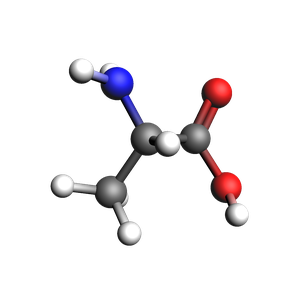

In [2]:
smiles = "CC(N)C(=O)O"
alanine = plams.from_smiles(smiles)
view(alanine, height=300, width=300)

## Initial system: alanine dimer

Pack two alanine molecules in a sphere with a density of 0.5 kg/L.

In [3]:
density = 0.5
mol = plams.packmol(alanine, n_molecules=2, density=density, sphere=True, seed=seed)

Optimize the dimer structure prior to the conformer search.

In [4]:
s = plams.Settings()
s.input.GFNFF = plams.Settings()
s.input.ams.Task = "GeometryOptimization"
s.input.ams.GeometryOptimization.Convergence.Quality = "VeryGood"
s.input.ams.GeometryOptimization.Maxiterations = 1300
s.input.ams.GeometryOptimization.Method = "Quasi-Newton"

job = plams.AMSJob(molecule=mol, settings=s)
job.run()
mol = job.results.get_main_molecule()

[19.03|15:42:22] JOB plamsjob STARTED
[19.03|15:42:22] JOB plamsjob RUNNING
[19.03|15:42:24] JOB plamsjob FINISHED
[19.03|15:42:24] JOB plamsjob SUCCESSFUL


Translate the system to be centered around the origin (needed for SphericalWall later):

In [5]:
mol.translate(-np.array(mol.get_center_of_mass()))

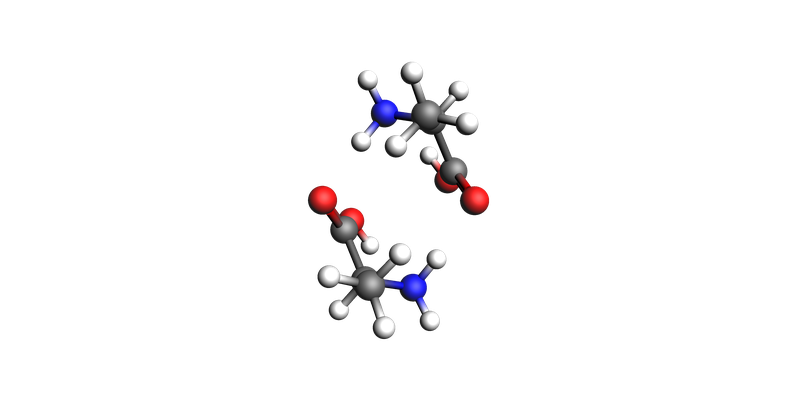

In [6]:
view(mol, direction="along_pca3")

## Calculation setup

To determine the radius of the `SphericalWall` we measure the size of the initial dimer.

In [7]:
dists = plams.distance_array(mol, mol)
max_dist = np.max(dists)
diameter = 1.33 * max_dist
radius = diameter / 2
print(f"Largest distance between atoms: {max_dist:.3f} ang.")
print(f"Radius: {radius:.3f} ang.")

Largest distance between atoms: 6.591 ang.
Radius: 4.383 ang.


Now we can set up the Crest conformer generation job, with the appropriate spherical wall constraining the molecules close together. The `NMolDynStepsFactor` keyword ensures that the metadynamics and regulat molecular dynamics simulations used in a crest exploration are three times longer than the default. The default setting is based on single molecule flexibility. For multiple molecules, a little more exploration is required.

In [8]:
nsteps = 3200

settings = plams.Settings()
settings.input.ams.EngineAddons.WallPotential.Enabled = "Yes"
settings.input.ams.EngineAddons.WallPotential.Radius = radius
settings.input.ams.Generator.Method = "CREST"
settings.input.ams.Output.KeepWorkDir = "Yes"
settings.input.ams.GeometryOptimization.MaxConvergenceTime = "High"
settings.input.ams.Generator.CREST.NCycles = 3  # at most 3 CREST cycles for this demo
settings.input.ams.Generator.RNGSeed = seed
settings.input.ams.Generator.CREST.NMolDynStepsFactor = 3
settings.input.GFNFF = plams.Settings()

## Run the conformers job

Now we can run the conformer generation job. This job will run for approximately 30 minutes.

In [9]:
job = ConformersJob(molecule=mol, settings=settings)
job.run()
# ConformersJob.load_external("plams_workdir/conformers/conformers.rkf")  # load from disk instead of running the job

[19.03|15:42:44] JOB conformers STARTED
[19.03|15:42:44] JOB conformers RUNNING
[19.03|16:24:02] JOB conformers FINISHED
[19.03|16:24:02] JOB conformers SUCCESSFUL


Now, remove the wall and reoptimize

In [10]:
if "EngineAddons" in settings.input.ams:
    del settings.input.ams.EngineAddons
settings.input.ams.Task = "Optimize"
settings.input.ams.InputConformersSet = job.results.rkfpath()
opt_job = ConformersJob(settings=settings)
opt_job.run()

[19.03|16:31:04] JOB conformers STARTED
[19.03|16:31:04] Renaming job conformers to conformers.002
[19.03|16:31:04] JOB conformers.002 RUNNING
[19.03|16:36:49] JOB conformers.002 FINISHED
[19.03|16:36:49] JOB conformers.002 SUCCESSFUL


In [11]:
rkf = opt_job.results.rkfpath()
print(f"Conformers stored in {rkf}")

Conformers stored in /path/plams/examples/ConformersMultipleMolecules/plams_workdir/conformers.002/conformers.rkf


## Results
Here we plot the three lowest-energy conformers.

In [12]:
def plot_conformers(job: ConformersJob, indices=None, temperature=298, unit="kcal/mol", lowest=True):
    molecules = job.results.get_conformers()
    energies = job.results.get_relative_energies(unit)
    populations = job.results.get_boltzmann_distribution(temperature)

    if isinstance(indices, int):
        N_plot = min(indices, len(energies))
        if lowest:
            indices = list(range(N_plot))
        else:
            indices = np.linspace(0, len(energies) - 1, N_plot, dtype=np.int32)
    if indices is None:
        indices = list(range(min(3, len(energies))))

    fig, axes = plt.subplots(1, len(indices), figsize=(12, 4))
    if len(indices) == 1:
        axes = [axes]

    for ax, i in zip(axes, indices):
        mol = molecules[i]
        E = energies[i]
        population = populations[i]

        if _has_view:
            img = view(mol, width=300, height=300)
            ax.imshow(img)
            ax.axis("off")
            ax.set_title(f"#{i+1}\nΔE = {E:.2f} kcal/mol\nPop.: {population:.3f} (T = {temperature} K)")
        else:
            view(mol, ax=ax)
            ax.set_title(f"#{i+1}\nΔE = {E:.2f} kcal/mol\nPop.: {population:.3f} (T = {temperature} K)")

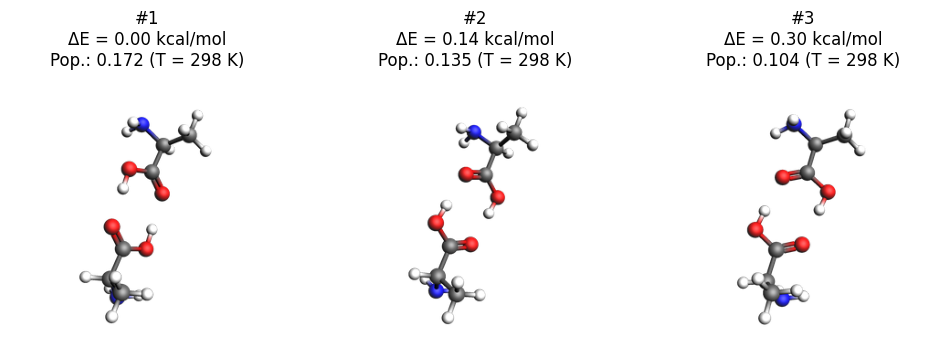

In [13]:
plot_conformers(opt_job)

You can also open the conformers in AMSmovie to browse all 1000+ conformers:

In [14]:
!amsmovie {rkf}

Finally in AMS2025+, you can also inspect the conformer data using the JobAnalysis tool.

In [15]:
try:
    from scm.plams import JobAnalysis

    ja = (
        JobAnalysis(standard_fields=None)
        .add_job(opt_job)
        .add_field(
            "Id",
            lambda j: list(range(1, len(j.results.get_conformers()) + 1)),
            display_name="Conformer Id",
            expansion_depth=1,
        )
        .add_field(
            "Energies",
            lambda j: j.results.get_relative_energies("kcal/mol"),
            display_name="E",
            expansion_depth=1,
            fmt=".2f",
        )
        .add_field(
            "Populations",
            lambda j: j.results.get_boltzmann_distribution(298),
            display_name="P",
            expansion_depth=1,
            fmt=".3f",
        )
    )

    # Pretty-print if running in a notebook
    if "ipykernel" in sys.modules:
        ja.display_table(max_rows=20)
    else:
        print(ja.to_table())

except ImportError:
    pass

| Conformer Id | E      | P     |
|--------------|--------|-------|
| 1            | 0.00   | 0.172 |
| 2            | 0.14   | 0.135 |
| 3            | 0.30   | 0.104 |
| 4            | 0.30   | 0.103 |
| 5            | 0.34   | 0.097 |
| 6            | 0.48   | 0.076 |
| 7            | 0.92   | 0.036 |
| 8            | 0.94   | 0.035 |
| 9            | 0.95   | 0.034 |
| 10           | 1.08   | 0.028 |
| ...          | ...    | ...   |
| 2474         | 24.80  | 0.000 |
| 2475         | 24.87  | 0.000 |
| 2476         | 94.53  | 0.000 |
| 2477         | 95.63  | 0.000 |
| 2478         | 96.05  | 0.000 |
| 2479         | 100.79 | 0.000 |
| 2480         | 101.51 | 0.000 |
| 2481         | 102.07 | 0.000 |
| 2482         | 106.84 | 0.000 |
| 2483         | 111.20 | 0.000 |